# Extracting PNR information from SNSPD waveform dataset


In [1]:
# Implementation code for each waveform (cutting the unecessary printing)
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
#Plotting the waveform
def plot_waveform(time, amplitude):
    fig = plt.figure()
    ax = plt.axes()
    ax.set(xlabel='Time(10ns)', ylabel='Voltage (mV)',
    title='Waveform of incident photon, unknown n')
    ax.plot( time*10**8, amplitude*1000, 'o', color = "blue")
# Reject samples with two or more peaks
# Our idea: Make an algorithm that identify how many peaks per sample
def count_peak(amplitude): # Count how many amplitude per sample, eliminate samples with > 1 amplitudes
    # Must be larger than 30mV. The STD for amplitude noise, estimated by the fluctuation in the zero line is around 7 mV, so i figure a 4*sigma is enough to seperate signal from noise
    #Must be larger than adjacent neighbors + adjacent -10 and +10 neighbors
    peak_index = []
    for i in range(len(amplitude)):
        if (i >= 11) and (i <= len(amplitude)-11):
            if (amplitude[i]*1000 > 30) and (amplitude[i] >= max(np.max(amplitude[i-11:i]),np.max(amplitude[i+1:i+11]))):
                if (i-1 not in peak_index) and (i-2 not in peak_index): # Some 2-3 consecutive sampling have equal amplitude, they are still one peak so we eliminate the rest
                    peak_index.append(i)
    return peak_index
# Centering the peak, all to t = 0
def center_waveform(time, peak_index):
    if len(peak_index) == 1:
        time = time - time[peak_index[0]]
        return time


In [2]:
#Analyzing the data
one_peak_waveforms = {}
minpeak = 120
for i in range(1,16392):
    k = i 
    string_k = str(k)
    for i in range(5-len(string_k)):
        string_k = '0' + string_k
    amplitude = []
    time = []
    with open(f'D:/NTU documents/NTU academic essentials/Research/PNR project with Dr.Anton/Dataset for Nguyen/{string_k}.txt') as waveform:
        i = 0
        for line in waveform:
            if i >= 5:
                line_list = line.split()
                time.append(line_list[0]) #This is good if there's no data missing, if there is later we apply a filter
                amplitude.append(line_list[1])
            i+=1 
    # Store the relevant information in a pd.Dataframe/Series
    time = np.array(time, dtype=float)
    amplitude = np.array(amplitude, dtype= float)
    #Identifying peaks:
    peak_index = count_peak(amplitude)
    #If peak is not 1, skip
    if len(peak_index) != 1:
        continue
    #If peak is one, recenter the waveform, append the data into a common respiratory for later implementation of dot products
    else:
        if amplitude[peak_index[0]]*1000 < minpeak:
            minpeak = amplitude[peak_index[0]]*1000 # Check to see if our 30mV filter (roughly 4*std) filters out signal 
        time = center_waveform(time, peak_index)
        waveform_info = np.vstack([time, amplitude])
        waveform_info_list = []
        waveform_info_list.append(1) #Initialize photon count of all to one, later will be modified. The waveform info list will contain the n_eff, amplitude and time information of each pulse
        waveform_info_list.append(waveform_info)
        one_peak_waveforms[string_k] = waveform_info_list # The overall structure of the one_peak_waveform list would be {(index of waveform):[neff,[ [time],[amplitude] ]]}
print(minpeak) # Testing if the 30mV filters out any signal, apparently it didn't

48.1674


253
6.320819029852558e-11
1.042594128608332
1.1202503290042944
1.4993569509014841
0.6161761155973943
1.1939850865652013
0.8275754859730873
0.7749226988567706
1.4717611276162093
0.7812883347173005
0.8099622480192404
0.700916258293668
0.8419792451101941
0.7208753336804586
0.7737954657206784
0.8212943906869669
0.8560085338364968
1.045509738310485
1.4902086161786439
1.4695785295530694
0.7728261107643712
1.469673498711086
0.7538528584858043
0.8208325699566866
0.8028820782797707
0.7219805075285393
0.8114855188721203
0.7751713548459915
0.7270564632855191
1.0597788879436576
0.729219214534224
0.8368542552345494
1.1284654967933005
1.1773814494822787
1.1402660095195765
0.9051994395854692
0.7539393270634192
0.6944927446766773
0.7204913280295506
1.4234006426258923
0.7348120227989114
1.1121528559217155
0.7977197877557789
0.7225792950225243
1.161803520661711
1.1458071964643912
0.7059556376285725
0.7364380896940144
1.4907143537265288
0.7537872991407604
0.7452693485042389
0.7805930769831805
1.452400437

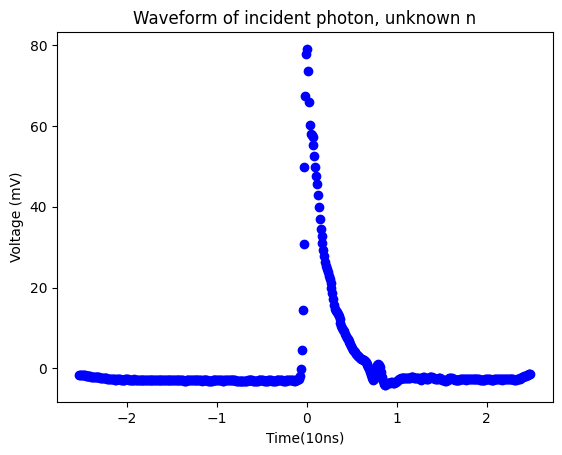

In [3]:
# Implement the dot product algorithm
# Calculating the mean waveform 
waveform_sum = np.zeros((2,502), dtype=float)
for waveform in one_peak_waveforms.values():
    waveform_sum += waveform[1]
waveform_average = waveform_sum/len(one_peak_waveforms)
#Plotting the average waveform
plot_waveform(waveform_average[0],waveform_average[1])
peak_index = count_peak(waveform_average[1])
print(peak_index[0]) #Index of peak
print(waveform_average[0][peak_index[0]]) # Time of peak
#Calulating the n_eff for each waveform, appending it in the  waveform_info_list
for waveform in one_peak_waveforms.values():
    #Performing the inner product
    n_eff = np.sum(waveform[1][1]*waveform_average)/np.sum(waveform_average**2)
    waveform[0] = n_eff  
n_eff_max = 0
n_eff_min = 2
n_eff_array = np.zeros(len(one_peak_waveforms)) # Arrays of value of n_eff
for i, waveform in enumerate(one_peak_waveforms.values()):
    n_eff = waveform[0]
    n_eff_array[i] = n_eff
    #Additional information 
    print(waveform[0])
    if n_eff >= n_eff_max:
        n_eff_max = n_eff
    if n_eff <= n_eff_min:
        n_eff_min = n_eff
    
print(f"n_eff_max: {n_eff_max}")
print(f"n_eff_min: {n_eff_min}")


111
peak amplitude: 470, peak index: 24
peak amplitude: 224, peak index: 59
peak amplitude: 156, peak index: 92
minima amplitude: 0, minima index: 6
minima amplitude: 2, minima index: 41
minima amplitude: 0, minima index: 75


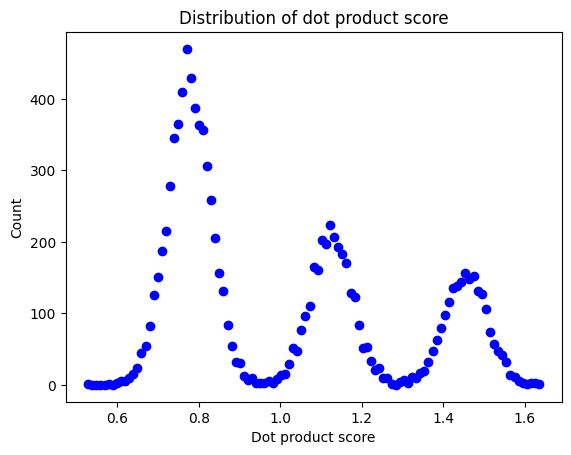

In [4]:
# Now, we are going to see whether or not the waveform is clusterable, by plotting the disturbution of n_eff
# Forming bins
bin_width = 0.1
bin_count = int((n_eff_max-n_eff_min)*10/bin_width)
print(bin_count)
#Plotting the n_eff_disturbution
hist, bin_edges = np.histogram(n_eff_array, bins = bin_count)
bin_mean = bin_edges[1:]-(bin_edges[1]-bin_edges[0])/2
# Plotting histogram fucntion
fig = plt.figure()
ax = plt.axes()
def plot_histogram(hist, bin_mean, fig, ax, color):
    ax.set(xlabel='Dot product score', ylabel='Count',
        title='Distribution of dot product score')
    ax.plot(bin_mean, hist ,'o', color = color)
plot_histogram(hist, bin_mean, fig, ax, "blue")
#The waveforms demonstrated strong clustering profile. Benchmarking the clustering using visibility
#Identify peak/ smallest points
def count_peak(amplitude): # Count how many amplitude per sample, eliminate samples with > 1 amplitudes
    # Must be larger than 30mV. The STD for amplitude noise, estimated by the fluctuation in the zero line is around 7 mV, so i figure a 4*sigma is enough to seperate signal from noise
    #Must be larger than adjacent neighbors + adjacent -10 and +10 neighbors
    peak_index = []
    for i in range(len(amplitude)):
        if (i >= 21) and (i <= len(amplitude)-5):
            if (amplitude[i] > 40) and (amplitude[i] >= max(np.max(amplitude[i-5:i]),np.max(amplitude[i+1:i+5]))):
                if (i-1 not in peak_index) and (i-2 not in peak_index): # Some 2-3 consecutive sampling have equal amplitude, they are still one peak so we eliminate the rest
                    peak_index.append(i)
    return peak_index
def count_minima(amplitude):
    minima_index = []
    for i in range(len(amplitude)):
        if (i >= 5) and (i <= len(amplitude)-5):
            if (amplitude[i] < 20) and (amplitude[i] <= min(np.min(amplitude[i-5:i]),np.min(amplitude[i+1:i+5]))):
                if (i-1 not in minima_index) and (i-2 not in minima_index): # Some 2-3 consecutive sampling have equal amplitude, they are still one peak so we eliminate the rest
                    minima_index.append(i)
    return minima_index
peak_index = count_peak(hist)
minima_index = count_minima(hist)
peak_amplitude = []
for peak in peak_index:
    print(f"peak amplitude: {hist[peak]}, peak index: {peak}")
for minima in minima_index:
    print(f"minima amplitude: {hist[minima]}, minima index: {minima}")


(array([4.28070043e+02, 7.76546960e-01, 5.26087449e-02]), array([[ 2.12632456e+01, -8.41412041e-07, -1.74395950e-03],
       [-8.41412041e-07,  4.28102525e-07,  2.30395172e-10],
       [-1.74395950e-03,  2.30395172e-10,  4.28732976e-07]]))
[4.28070043e+02 7.76546960e-01 5.26087449e-02]
0.8598792147766311
32
41
(array([2.12478149e+02, 1.12463741e+00, 5.07653371e-02]), array([[ 9.97435581e+00, -8.07595002e-07, -1.59050141e-03],
       [-8.07595002e-07,  7.58936664e-07,  4.30506995e-10],
       [-1.59050141e-03,  4.30506995e-10,  7.60144975e-07]]))
[2.12478149e+02 1.12463741e+00 5.07653371e-02]
1.1210990643836742
29
34
(array([1.55251168e+02, 1.45483816e+00, 5.26066952e-02]), array([[ 3.21957150e+00,  3.18592204e-08, -7.27466640e-04],
       [ 3.18592204e-08,  4.92852525e-07, -2.35505080e-11],
       [-7.27466640e-04, -2.35505080e-11,  4.93016617e-07]]))
[1.55251168e+02 1.45483816e+00 5.26066952e-02]
0.5021807851133171
27
36


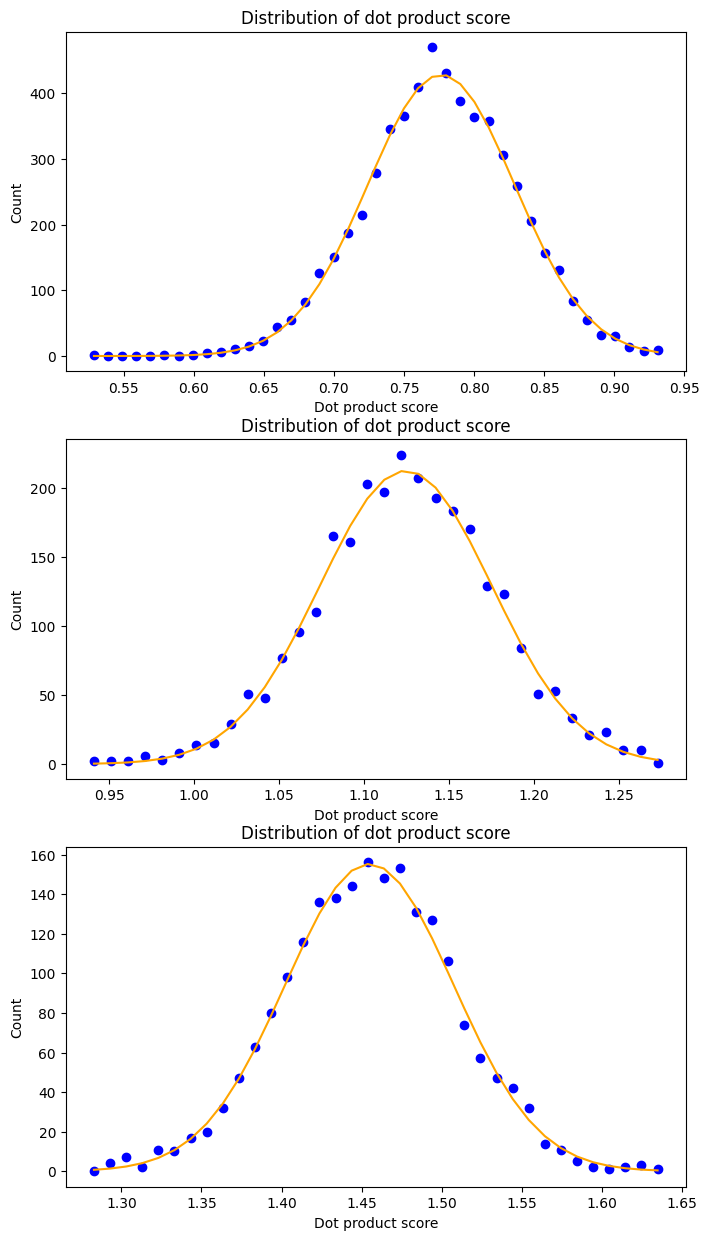

In [6]:
#Fitting our data to Gaussian functions 
#Divide our dataset to three portion at our minima at index 84 and 149
sep_1 = 41
sep_2 = 75
hist_1 = hist[:sep_1]
bin_mean_1 = bin_mean[:sep_1]
hist_2 = hist[sep_1:sep_2]
bin_mean_2 = bin_mean[sep_1:sep_2]
hist_3 = hist[sep_2:]
bin_mean_3 = bin_mean[sep_2:]
#Plot them for the sake of visualization
fig, ax = plt.subplots(3,figsize=(8, 15))
plot_histogram(hist_1,bin_mean_1,fig, ax[0],'blue')
plot_histogram(hist_2, bin_mean_2,fig, ax[1],'blue')
plot_histogram(hist_3,bin_mean_3,fig, ax[2],'blue')
# Fitting the data to Gaussian function, minimizing sum of square error
from scipy.optimize import curve_fit
def Gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
# def function for reduced X^2
def reduced_chi_sq(y_data, y_pred, c):
    mask = y_pred >= 5          # The count in each bin should be five or more
    y_d  = y_data[mask]
    y_p  = y_pred[mask]
    dof  = len(y_d) - c
    return np.sum((y_d - y_p)**2 / y_p) / dof
#Plot 1
popt_1 = curve_fit(Gaussian, bin_mean_1, hist_1, p0 = [225, 0.78, 0.2])
print(popt_1)
param_1 = popt_1[0]
print(param_1)
ax[0].plot(bin_mean_1, Gaussian(bin_mean_1, param_1[0], param_1[1], param_1[2]),'-', color = 'orange')
print(reduced_chi_sq(hist_1, Gaussian(bin_mean_1, param_1[0], param_1[1], param_1[2]), 3 ))
print(len(hist_1[hist_1>5]))
print(len(hist_1))
#Plot 2
popt_2 = curve_fit(Gaussian, bin_mean_2, hist_2, p0 = [125, 1.15, 0.2])
print(popt_2)
param_2 = popt_2[0]
print(param_2)
ax[1].plot(bin_mean_2, Gaussian(bin_mean_2, param_2[0], param_2[1], param_2[2]),'-', color = 'orange')
print(reduced_chi_sq(hist_2, Gaussian(bin_mean_2, param_2[0], param_2[1], param_2[2]), 3))
print(len(hist_2[hist_2>5]))
print(len(hist_2))
#Plot 3
popt_3 = curve_fit(Gaussian, bin_mean_3, hist_3, p0 = [80, 1.45, 0.2])
print(popt_3)
param_3 = popt_3[0]
print(param_3)
ax[2].plot(bin_mean_3, Gaussian(bin_mean_3, param_3[0], param_3[1], param_3[2]),'-', color = 'orange')
print(reduced_chi_sq(hist_3, Gaussian(bin_mean_3, param_3[0], param_3[1], param_3[2]), 3))
print(len(hist_3[hist_3>5]))
print(len(hist_3))

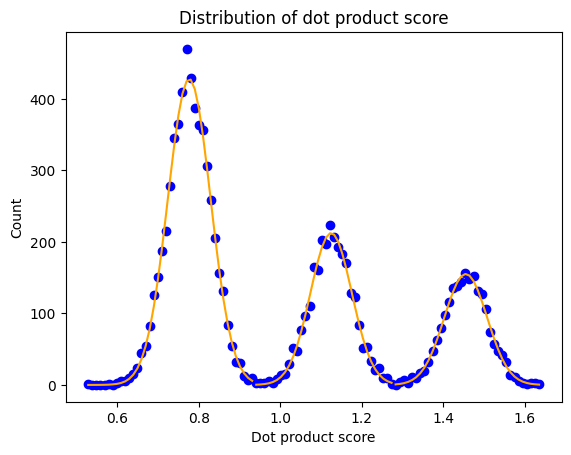

In [8]:
#Final plot
fig = plt.figure()
ax = plt.axes()
plot_histogram(hist, bin_mean, fig, ax,'blue')
ax.plot(bin_mean_1, Gaussian(bin_mean_1, param_1[0], param_1[1], param_1[2]),'-', color = 'orange')
ax.plot(bin_mean_2, Gaussian(bin_mean_2, param_2[0], param_2[1], param_2[2]),'-', color = 'orange')
ax.plot(bin_mean_3, Gaussian(bin_mean_3, param_3[0], param_3[1], param_3[2]),'-', color = 'orange')


[4.26856477e+02 7.76069135e-01 5.29566804e-02 2.09283393e+02
 1.12496641e+00 5.20956418e-02 1.55130951e+02 1.45460478e+00
 5.27771382e-02]
The reduced chi square: 0.7007619414633239
0.772969077904303


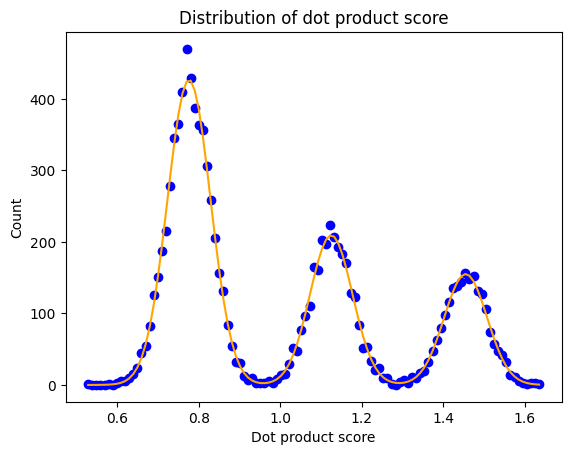

In [10]:
# Our data overlaps strongly, in other words, noise from one peak could "mitigate" and be measured in other peaks too
# --> We should fit to a three-peak single gaussian function, not dividing the dataset into three parts
# The data on the first part do provide a good starting point
from scipy.optimize import minimize

def three_peak_gaussian(x, params):
    A_1, mu_1, sigma_1, A_2, mu_2, sigma_2, A_3, mu_3, sigma_3 = params
    return (A_1 * np.exp(-0.5 * ((x - mu_1) / sigma_1)**2) +
            A_2 * np.exp(-0.5 * ((x - mu_2) / sigma_2)**2) +
            A_3 * np.exp(-0.5 * ((x - mu_3) / sigma_3)**2))

def reduced_chisquare_threepeakgaussian(params):
    return reduced_chi_sq(hist, three_peak_gaussian(bin_mean, params), 3)

OptimizeResult = minimize(reduced_chisquare_threepeakgaussian, x0=np.array([
    4.28070043e+02, 7.76546960e-01, 5.26087449e-02,
    2.12478149e+02, 1.12463741e+00, 5.07653371e-02,
    1.55251168e+02, 1.45483816e+00, 5.26066952e-02
]))
print(OptimizeResult.x)
fig = plt.figure()
ax = plt.axes()
plot_histogram(hist, bin_mean, fig, ax,'blue')
ax.plot(bin_mean, three_peak_gaussian(bin_mean, OptimizeResult.x),'-', color = 'orange')
print(f"The reduced chi square: {reduced_chi_sq(hist, three_peak_gaussian(bin_mean, OptimizeResult.x),3)}")
# Calculate the chi square of the previous approach of three seperate gaussians
count_pred_1 = Gaussian(bin_mean_1, param_1[0], param_1[1], param_1[2])
count_pred_2 = Gaussian(bin_mean_2, param_2[0], param_2[1], param_2[2])
count_pred_3 = Gaussian(bin_mean_3, param_3[0], param_3[1], param_3[2])
count_pred = np.concatenate([count_pred_1,count_pred_2,count_pred_3])
print(reduced_chi_sq(hist, count_pred, 3))

Minima 1: x = 0.95801, f(x) = 2.3988
Minima 2: x = 1.29161, f(x) = 2.5724


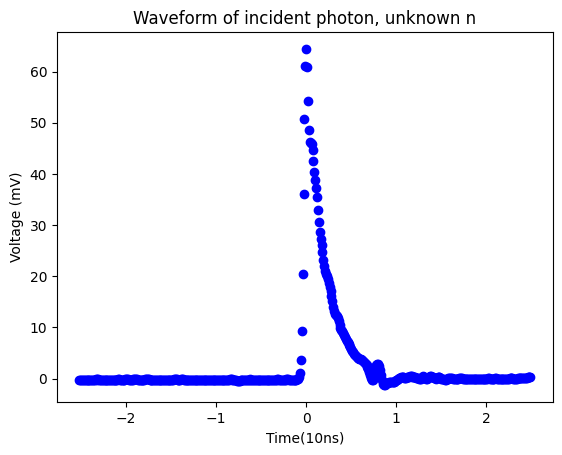

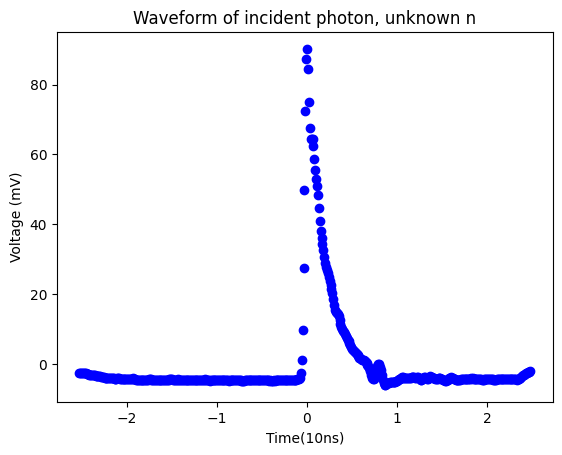

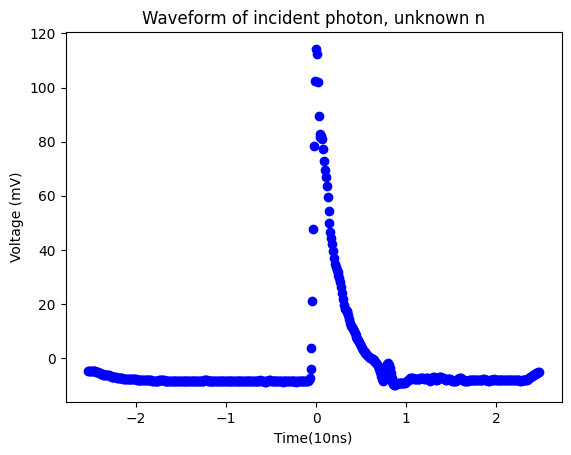

In [11]:
# Analyzing more closely the results of our dot-product clustering. We want to find roughly the waveforms that 
# belongs to each clusters (divided using minima by the fit), and the average waveform for each clusters.
# The average/characteristic waveform for each cluster will be taken around bins centered at the fitted bins for each peak.

#Finding minima to 'split' our cluster
import copy
import numpy as np
from scipy.optimize import minimize_scalar

A1, mu_1, s1 = 4.26856477e+02, 7.76069135e-01, 5.29566804e-02
A2, mu_2, s2 = 2.09283393e+02, 1.12496641e+00, 5.20956418e-02
A3, mu_3, s3 = 1.55130951e+02, 1.45460478e+00, 5.27771382e-02

def f(x):
    g1 = A1 * np.exp(-0.5 * ((x - mu_1)/s1)**2)
    g2 = A2 * np.exp(-0.5 * ((x - mu_2)/s2)**2)
    g3 = A3 * np.exp(-0.5 * ((x - mu_3)/s3)**2)
    return g1 + g2 + g3

# Minima between peaks — minimize f in each valley
res1 = minimize_scalar(f, bounds=(mu_1, mu_2), method='bounded')
res2 = minimize_scalar(f, bounds=(mu_2, mu_3), method='bounded')

print(f"Minima 1: x = {res1.x:.5f}, f(x) = {res1.fun:.4f}")
print(f"Minima 2: x = {res2.x:.5f}, f(x) = {res2.fun:.4f}")

#Dividing our dataset in terms of these parameters, and calculate their characteristic waveform
group_1_waveforms = {}
group_2_waveforms = {}
group_3_waveforms = {}

for index in one_peak_waveforms.keys():
    if one_peak_waveforms[index][0] < res1.x:
        group_1_waveforms[index] = copy.deepcopy(one_peak_waveforms[index])
    if one_peak_waveforms[index][0] >=  res1.x and one_peak_waveforms[index][0] < res2.x:
        group_2_waveforms[index] = copy.deepcopy(one_peak_waveforms[index])
    if one_peak_waveforms[index][0] > res2.x:
        group_3_waveforms[index] = copy.deepcopy(one_peak_waveforms[index])

clusters = [group_1_waveforms, group_2_waveforms, group_3_waveforms]

#Getting their characteristic waveform: Our method is to pick the bin where the center of each gaussian value lies in, and takes it's waveform average

char_waveform_1 = np.zeros((2,502), dtype=float)
char_waveform_2 = np.zeros((2,502), dtype=float)
char_waveform_3 = np.zeros((2,502), dtype=float)

char_waveforms = [char_waveform_1, char_waveform_2, char_waveform_3]

for k, cluster in enumerate(clusters):
    waveform_sum = np.zeros((2,502), dtype=float)
    i = 0
    for waveform in cluster.values():
        waveform_sum += waveform[1]
        i += 1
    waveform_average = waveform_sum/i
    char_waveforms[k] = waveform_average
char_waveform_1, char_waveform_2, char_waveform_3 = char_waveforms  # unpack explicitly

for char_waveform in char_waveforms:
    plot_waveform(char_waveform[0], char_waveform[1])


## Second algorithm: Poisson-Influenced K-means algorithm
The K-mean algo is an unsupervised learning algorithm, which means we can test that on to our data set, if we think of our function V(t) as a point in high-dimensional space

[[-0.00330712 -0.00330712 -0.00496759 ... -0.00496759 -0.00662806
  -0.00496759]
 [-0.00330712 -0.00496759 -0.00662806 ... -0.00994899 -0.00994899
  -0.00994899]
 [-0.00994899 -0.00828852 -0.00662806 ... -0.00496759 -0.00330712
  -0.00330712]
 ...
 [-0.00164665 -0.00496759 -0.00662806 ...  0.00499522  0.00499522
  -0.00164665]
 [ 0.00665569  0.00333475  0.00499522 ... -0.00662806 -0.00828852
  -0.00662806]
 [-0.00828852 -0.00828852 -0.00828852 ...  0.00499522  0.00333475
  -0.00330712]]


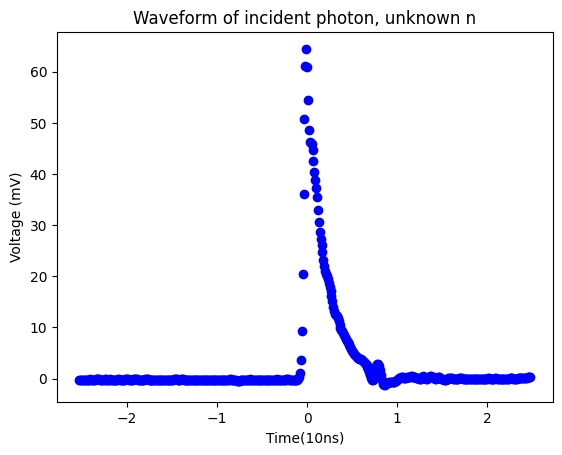

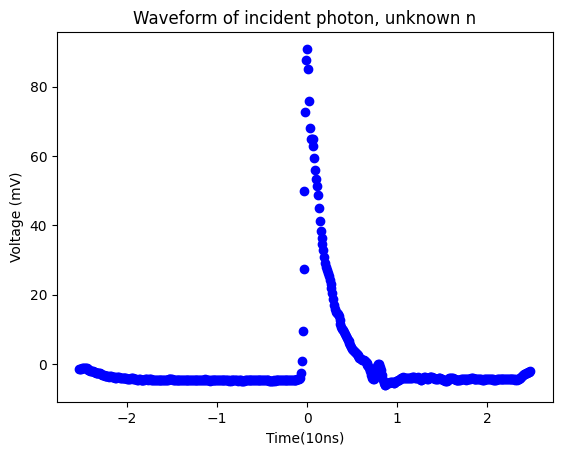

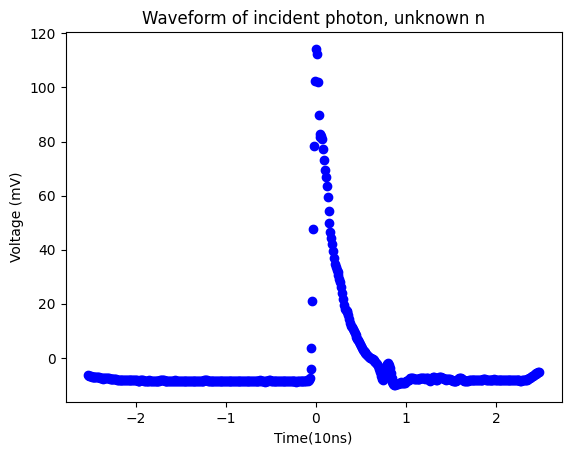

In [12]:
# Implementing K-mean:
from sklearn.cluster import KMeans
X = []
for waveform in one_peak_waveforms.values():
    amplitude = waveform[1][1]
    X.append(amplitude)
X = np.array(X)
print(X)
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(X)
kmeans.labels_
#Visualizing clusters center
amplitude_1 = kmeans.cluster_centers_[1]
amplitude_2 = kmeans.cluster_centers_[2]
amplitude_3 = kmeans.cluster_centers_[0]
time = one_peak_waveforms['00003'][1][0]
cluster_center_1 = np.vstack([time, amplitude_1])
cluster_center_2 = np.vstack([time, amplitude_2])
cluster_center_3 = np.vstack([time, amplitude_3])
cluster_centers = [cluster_center_1, cluster_center_2, cluster_center_3]
for cluster_center in cluster_centers:
    plot_waveform(cluster_center[0], cluster_center[1])
cluster_kmean_1  = {}
cluster_kmean_2  = {}
cluster_kmean_3  = {}
clusters = [cluster_kmean_3, cluster_kmean_1, cluster_kmean_2]
# Sorting clusters into cluster center using kmean
for index in one_peak_waveforms.keys():
    waveform = one_peak_waveforms[index][1][1]
    i = kmeans.predict(waveform.reshape(1, -1))
    clusters[i[0]][index] = copy.deepcopy(one_peak_waveforms[index])


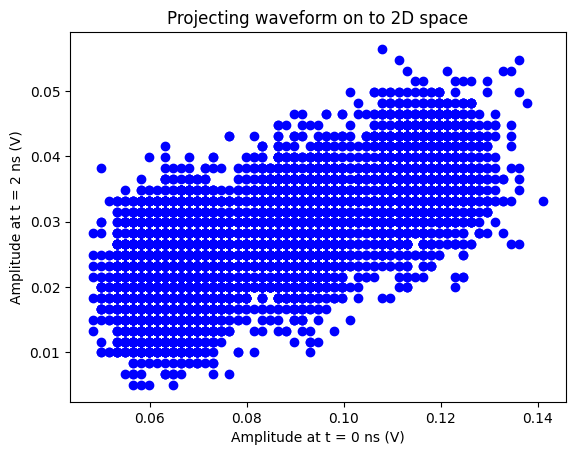

In [13]:
# Visualzing the dataset by projecting it on to 2D, at t = 0 and t = 2 ns. We will see how the cluster distributes itself, and how the dot product cluster it
fig = plt.figure()
ax = plt.axes()
ax.set(xlabel='Amplitude at t = 0 ns (V)', ylabel='Amplitude at t = 2 ns (V)',
    title='Projecting waveform on to 2D space')
# Array of amplitude at t = 0 and t = 2
amplitude_t_0 = []
amplitude_t_2 = []
for waveform in one_peak_waveforms.values():
    index_0 = np.argmin(np.abs(waveform[1][0]))
    index_2 = index_0 + 20 # index_2 = index_0 + number of samples to 2ns
    amplitude_t_0.append(waveform[1][1][index_0])
    amplitude_t_2.append(waveform[1][1][index_2])
ax.scatter(amplitude_t_0, amplitude_t_2, marker='o', color='blue')


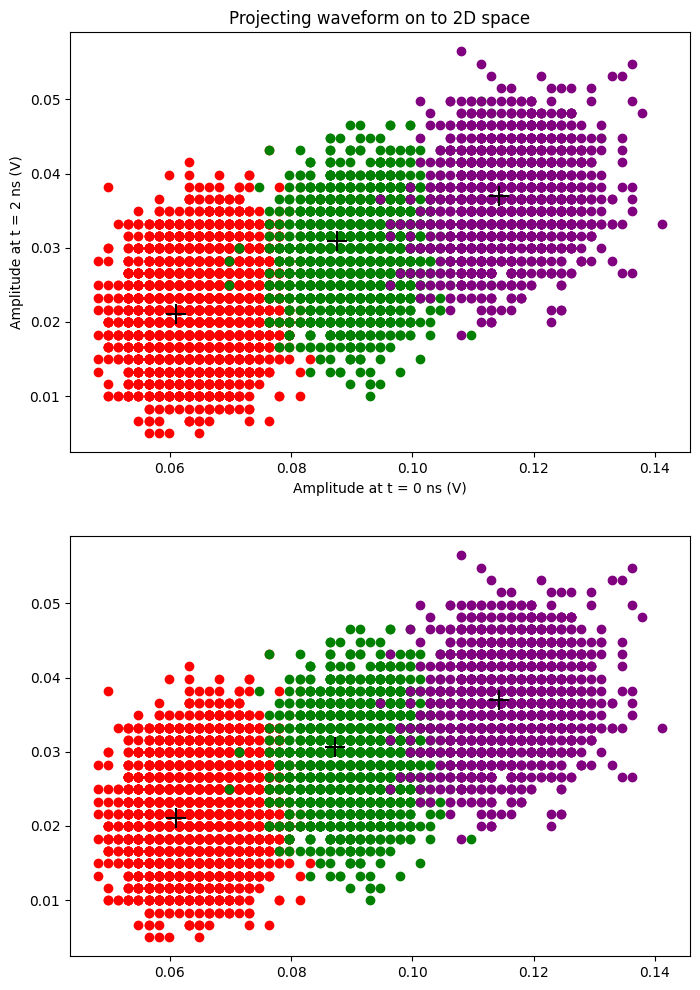

In [14]:
# Benchmarking our two methods: Projecting it onto 2D space as prior
# Visualzing the dataset by projecting it on to 2D, at t = 0 and t = 2 ns. We will see how the cluster distributes itself, and how the dot product cluster it
fig, ax = plt.subplots(2, figsize=(8, 12))
ax[0].set(xlabel='Amplitude at t = 0 ns (V)', ylabel='Amplitude at t = 2 ns (V)',
    title='Projecting waveform on to 2D space')
cluster_centers_kmean = [cluster_center_1, cluster_center_2, cluster_center_3]
char_waveforms_dot = [char_waveform_1, char_waveform_2, char_waveform_3]

# Array of amplitude at t = 0 and t = 2
for cluster, color, cluster_center in zip([cluster_kmean_1, cluster_kmean_2, cluster_kmean_3], ['red', 'green', 'purple'], cluster_centers_kmean):
    amplitude_t_0, amplitude_t_2 = [], []
    for waveform in cluster.values():
        index_0 = np.argmin(np.abs(waveform[1][0]))
        amplitude_t_0.append(waveform[1][1][index_0])
        amplitude_t_2.append(waveform[1][1][index_0 + 20])
    ax[0].scatter(amplitude_t_0, amplitude_t_2, marker='o', color=color)
    center_index_0 = np.argmin(np.abs(cluster_center[0]))  # fix
    ax[0].scatter(cluster_center[1][index_0], cluster_center[1][index_0 + 20], marker='+', s=200, color="black")
for cluster, color, cluster_center in zip([group_1_waveforms, group_2_waveforms, group_3_waveforms], ['red', 'green', 'purple'], char_waveforms_dot):
    amplitude_t_0, amplitude_t_2 = [], []
    for waveform in cluster.values():
        index_0 = np.argmin(np.abs(waveform[1][0]))
        amplitude_t_0.append(waveform[1][1][index_0])
        amplitude_t_2.append(waveform[1][1][index_0 + 20])
    ax[1].scatter(amplitude_t_0, amplitude_t_2, marker='o', color=color)
    center_index_0 = np.argmin(np.abs(cluster_center[0]))  # fix
    ax[1].scatter(cluster_center[1][index_0], cluster_center[1][index_0 + 20], marker='+', s=200, color="black")

n_eff_max1: 1.5989932537798874
n_eff_min1: 0.4191834313230982
n_eff_avg1: 1.0001349323405722
n_eff_max2: 2.4853363748833663
n_eff_min2: 1.1611484771108143
n_eff_avg2: 2.000212937562059
n_eff_max3: 3.650235019743615
n_eff_min3: 1.9346831230116321
n_eff_avg3: 2.9998561937433506
n_eff_max1: 1.495704004255856
n_eff_min1: 0.4152437898947168
n_eff_avg1: 1.000137831059264
n_eff_max2: 2.4928514912209723
n_eff_min2: 0.9660859471857157
n_eff_avg2: 2.0001661856987307
n_eff_max3: 3.6573368119172964
n_eff_min3: 2.5
n_eff_avg3: 2.9998757984946964


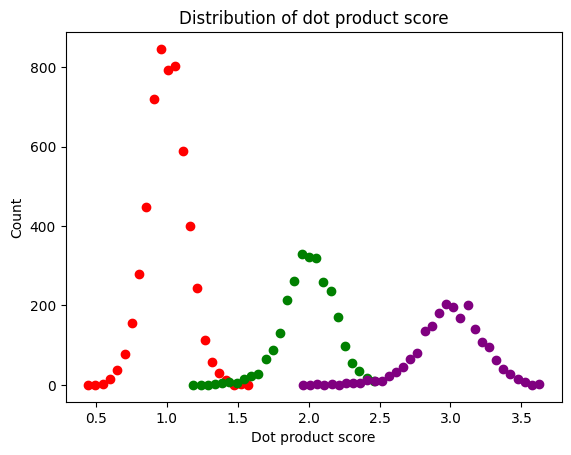

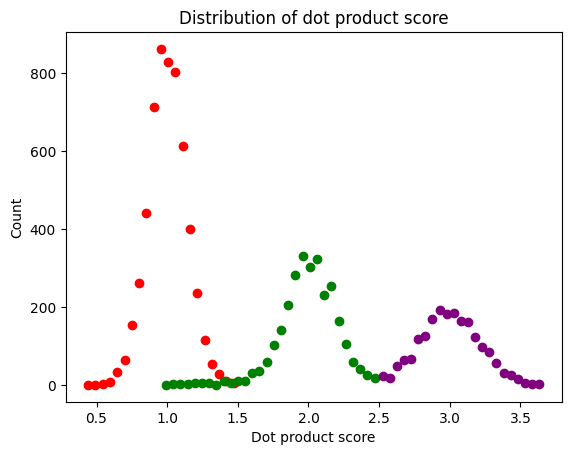

In [35]:
#Benchmarking the algos using visibility
# Deriving interpolated photon number. The cluster groups are sorted by voltage amplitude, from high to low
clusters_dot = [group_1_waveforms, group_2_waveforms, group_3_waveforms]
clusters_kmean = [cluster_kmean_1, cluster_kmean_2, cluster_kmean_3]
cluster_groups = [clusters_dot, clusters_kmean]
# Cluster mean 
cluster_centers_kmean = [cluster_center_1, cluster_center_2, cluster_center_3]
cluster_centers_dot = [char_waveform_1, char_waveform_2, char_waveform_3]
cluster_means = [cluster_centers_dot, cluster_centers_kmean]
#Finding alpha that minimizes rms error
def rms_error(V_1, V_2):
    return np.sqrt(np.sum((V_2 - V_1)**2) / len(V_1))
# Assigning each waveform an interpolated "photon number"
n_eff_results = {'dot': {}, 'kmean': {}}

for (cluster_group, cluster_mean, method) in zip(cluster_groups, cluster_means, ['dot', 'kmean']): 
    n = 1
    for cluster in cluster_group:
        for index in cluster.keys():
            n_prime = 1
            alpha = 4
            for k in [n-1, n+1]:
                if k == 0 or k == 4:
                    continue
                V_n = cluster_mean[n-1][1]
                V_n_2 = cluster_mean[k-1][1]
                V_i = cluster[index][1][1]
                def rms_waveform(alpha):
                    return rms_error(V_i, ((1-alpha)*V_n + alpha*V_n_2))
                a = minimize(rms_waveform, x0=np.array([0.5]))
                if rms_waveform(a.x[0]) <= rms_waveform(alpha):
                    alpha = a.x[0]
                    n_prime = k
            n_eff_results[method][index] = (1-alpha)*n + alpha*n_prime
        n += 1
fig = plt.figure()
ax = plt.axes()
for i, cluster, color in zip(range(len(clusters_dot)), clusters_dot, ['red', 'green', 'purple']):
    n_eff_array = np.array([n_eff_results['dot'][index] for index in cluster.keys()])
    n_eff_max = np.max(n_eff_array)
    n_eff_min = np.min(n_eff_array)
    print(f"n_eff_max{i+1}: {n_eff_max}")
    print(f"n_eff_min{i+1}: {n_eff_min}")
    print(f"n_eff_avg{i+1}: {np.average(n_eff_array)}")
    bin_width = 0.05
    bin_count = max(1, int((n_eff_max - n_eff_min) / bin_width))
    hist, bin_edges = np.histogram(n_eff_array, bins=bin_count)
    bin_mean = bin_edges[1:] - (bin_edges[1] - bin_edges[0]) / 2
    plot_histogram(hist, bin_mean, fig, ax, color)

# K-means clustering
fig = plt.figure()
ax = plt.axes()
for i, cluster, color in zip(range(len(clusters_kmean)), clusters_kmean, ['red', 'green', 'purple']):
    n_eff_array = np.array([n_eff_results['kmean'][index] for index in cluster.keys()])
    n_eff_max = np.max(n_eff_array)
    n_eff_min = np.min(n_eff_array)
    print(f"n_eff_max{i+1}: {n_eff_max}")
    print(f"n_eff_min{i+1}: {n_eff_min}")
    print(f"n_eff_avg{i+1}: {np.average(n_eff_array)}")
    bin_width = 0.05
    bin_count = max(1, int((n_eff_max - n_eff_min) / bin_width))
    hist, bin_edges = np.histogram(n_eff_array, bins=bin_count)
    bin_mean = bin_edges[1:] - (bin_edges[1] - bin_edges[0]) / 2
    plot_histogram(hist, bin_mean, fig, ax, color)
#Fitting interpolated photon number into gaussians, and visualizing the distribution 
# Forming bins



64

--- Dot Product ---
Fit params: [8.21526294e+02 1.00076217e+00 1.38560971e-01 3.17685085e+02
 2.00716495e+00 1.74239229e-01 1.99308707e+02 3.01463524e+00
 2.02790602e-01]
chi-square: 81.2100
64

--- K-Means ---
Fit params: [-4.51727378e+03  2.33836610e+01  1.11963113e+01 -4.41858880e+03
  1.89150939e+00 -1.66376167e+00 -1.46001640e+03  2.77776579e+00
  2.91424251e+00]
chi-square: 0.0000


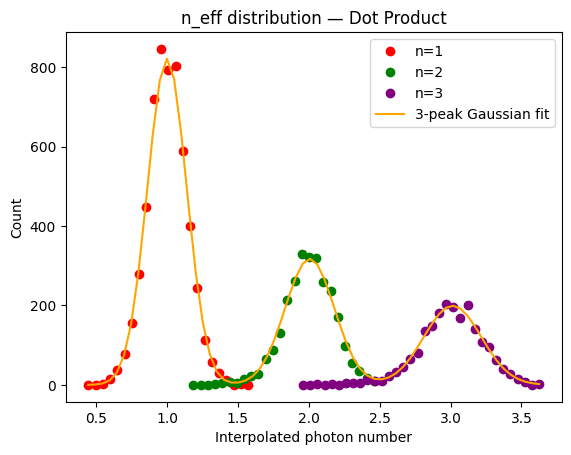

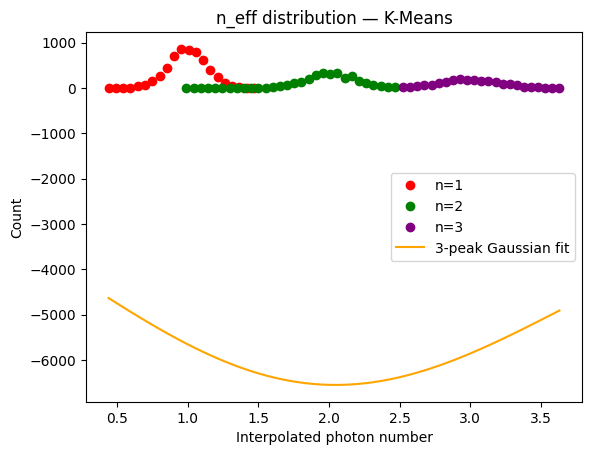

In [36]:
#Fitting the Gaussians, calculate the visibility 
from scipy.optimize import minimize

def three_peak_gaussian(x, params):
    A_1, mu_1, sigma_1, A_2, mu_2, sigma_2, A_3, mu_3, sigma_3 = params
    return (A_1 * np.exp(-0.5 * ((x - mu_1) / sigma_1)**2) +
            A_2 * np.exp(-0.5 * ((x - mu_2) / sigma_2)**2) +
            A_3 * np.exp(-0.5 * ((x - mu_3) / sigma_3)**2))

def chi_sq(y_data, y_pred):
    mask = y_pred >= 5
    y_d  = y_data[mask]
    y_p  = y_pred[mask]
    return np.sum((y_d - y_p)**2 / y_p) 

for method, cluster_group, title in zip(
    ['dot', 'kmean'],
    [clusters_dot, clusters_kmean],
    ['Dot Product', 'K-Means']
):
    # Collect all n_eff values across all clusters
    all_n_eff = np.concatenate([
        np.array([n_eff_results[method][index] for index in cluster.keys()])
        for cluster in cluster_group
    ])

    # Build histogram
    bin_width = 0.05
    n_eff_max, n_eff_min = np.max(all_n_eff), np.min(all_n_eff)
    bin_count = max(1, int((n_eff_max - n_eff_min) / bin_width))
    print(bin_count)
    hist, bin_edges = np.histogram(all_n_eff, bins=bin_count)
    bin_mean = bin_edges[1:] - (bin_edges[1] - bin_edges[0]) / 2

    # Fit three-peak Gaussian
    def chisquare_fit(params):
        return chi_sq(hist, three_peak_gaussian(bin_mean, params))

    result = minimize(chisquare_fit, x0=np.array([
        800, 1.0, 0.5,
        400, 2.0, 0.5,
        200, 3.0, 0.5,
    ]))

    # Plot
    fig = plt.figure()
    ax = plt.axes()
    ax.set(xlabel='Interpolated photon number', ylabel='Count', title=f'n_eff distribution — {title}')
    # Plot each cluster separately with color
    for i, cluster, color in zip(range(len(cluster_group)), cluster_group, ['red', 'green', 'purple']):
        n_eff_array = np.array([n_eff_results[method][index] for index in cluster.keys()])
        n_eff_max, n_eff_min = np.max(n_eff_array), np.min(n_eff_array)
        bin_count = max(1, int((n_eff_max - n_eff_min) / bin_width))
        h, edges = np.histogram(n_eff_array, bins=bin_count)
        bm = edges[1:] - (edges[1] - edges[0]) / 2
        ax.plot(bm, h, 'o', color=color, label=f'n={i+1}')
    ax.plot(bin_mean, three_peak_gaussian(bin_mean, result.x), '-', color='orange', label='3-peak Gaussian fit')
    ax.legend()
    print(f"\n--- {title} ---")
    print(f"Fit params: {result.x}")
    print(f"chi-square: {chi_sq(hist, three_peak_gaussian(bin_mean, result.x)):.4f}")

In [ ]:
#Benchmarking visibility
